## Tasks

### Task 1 — Hypothesis Testing

Based on your Day 6 findings, formulate **at least one testable hypothesis**. For each, specify:

- **H₀ (null hypothesis)**: The default "no effect" claim
- **H₁ (alternative hypothesis)**: What you suspect is true
- **Test you will use**: t-test, Welch's t-test, Mann-Whitney U, chi-square, ANOVA, etc.
- **Why this test**: Justify based on data type, distribution assumptions, and sample size

**Example hypotheses** (create your own based on your data):

| # | Hypothesis | Test |
|---|-----------|------|
| 1 | Mean summer temperature in City A has increased between 2019–2021 and 2022–2024 | Welch's two-sample t-test |
| 2 | The proportion of "dry days" (precipitation = 0) is different in City A vs City B | Chi-square test of independence |
| 3 | Mean daily temperature range is different across all four seasons | One-way ANOVA |

Before running each test, verify its assumptions (normality, equal variances, independence) and document them. After running the test, report the p-value, test statistic, and interpret the result in plain language.

> **Want to go further?** Test additional hypotheses, compute effect sizes (Cohen's d, Cramer's V), and apply Bonferroni or Benjamini-Hochberg correction for multiple comparisons.


In [1]:
import pandas as pd
import numpy as np
import sys
import os
import duckdb
sys.path.append(os.path.abspath(".."))

from src.database import get_connection


conn = duckdb.connect('../data/database/weather_daily.duckdb')

df = conn.execute("""
    SELECT *
    FROM analytics.weather_features_historical
""").df()

# safety
if df.empty:
    raise ValueError("❌ No data in analytics layer")

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
df.head()

IOException: IO Error: Could not set lock on file "/Users/samil/Desktop/ITSkillsSprintProjects/construction-weather-risk-planner/notebooks/../data/database/weather_daily.duckdb": Conflicting lock is held in /opt/anaconda3/envs/ironhack/bin/python3.11 (PID 67636) by user samil. See also https://duckdb.org/docs/stable/connect/concurrency

In [ ]:
# əlavə helper columns

df["month"] = df["date"].dt.month

# season artıq var amma yoxdursa:
if "season" not in df.columns:
    df["season"] = df["month"].map({
        12:"winter", 1:"winter", 2:"winter",
        3:"spring", 4:"spring", 5:"spring",
        6:"summer", 7:"summer", 8:"summer",
        9:"autumn", 10:"autumn", 11:"autumn"
    })

# rain flag
df["is_rain"] = df["precipitation_sum"] > 0

In [ ]:
"""
HYPOTHESIS 1

H₀: Mean temperature is equal across all seasons
H₁: At least one season has a different mean temperature

Test: One-way ANOVA

Why:
- Multiple groups (4 seasons)
- Continuous variable (temperature)
- Comparing means across groups
"""


import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro

# normality check (sample)
for season in df["season"].unique():
    sample = df[df["season"] == season]["temp_mean"].dropna().sample(500, random_state=42)
    stat, p = shapiro(sample)
    print(f"{season} → p-value: {p:.4f}")

spring → p-value: 0.0133
summer → p-value: 0.0000
autumn → p-value: 0.0093
winter → p-value: 0.0594


In [ ]:
from scipy.stats import f_oneway

groups = [
    df[df["season"] == s]["temp_mean"].dropna()
    for s in df["season"].unique()
]

stat, p = f_oneway(*groups)

print("ANOVA Statistic:", stat)
print("p-value:", p)


if p < 0.05:
    print("Reject H0: Temperature differs across seasons")
else:
    print("Fail to reject H0: No significant difference")

ANOVA Statistic: 5210.710809322142
p-value: 0.0
Reject H0: Temperature differs across seasons


In [ ]:
from scipy.stats import kruskal

groups = [
    df[df["season"] == s]["temp_mean"].dropna()
    for s in df["season"].unique()
]

stat, p = kruskal(*groups)

print("Kruskal Statistic:", stat)
print("p-value:", p)

if p < 0.05:
    print("Reject H0: Temperature differs across seasons")
else:
    print("Fail to reject H0: No significant difference")

Kruskal Statistic: 5030.981056924662
p-value: 0.0
Reject H0: Temperature differs across seasons


Although normality tests (Shapiro-Wilk) indicate deviations from normality (p < 0.05),
the large sample size (n > 7000) allows us to rely on ANOVA due to the Central Limit Theorem.

To ensure robustness, we also perform the non-parametric Kruskal-Wallis test.

Both ANOVA (F = 5210.65, p < 0.001) and Kruskal-Wallis (H = 5030.92, p < 0.001) tests indicate a statistically significant difference in temperature across seasons.

Given the large sample size, ANOVA is robust despite normality violations. The Kruskal-Wallis test confirms this result without relying on distributional assumptions.

Therefore, we reject the null hypothesis and conclude that temperature varies significantly by season.

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["temp_mean"],
    groups=df["season"],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
autumn spring  -1.8738   0.0  -2.3166  -1.4311   True
autumn summer  10.1928   0.0   9.7482  10.6374   True
autumn winter -11.3974   0.0 -11.8442 -10.9505   True
spring summer  12.0666   0.0  11.6251  12.5081   True
spring winter  -9.5235   0.0  -9.9673  -9.0798   True
summer winter -21.5901   0.0 -22.0357 -21.1445   True
-----------------------------------------------------


In [ ]:
import numpy as np

def cohens_d(x, y):
    nx, ny = len(x), len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * x.var() + (ny - 1) * y.var()) / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_std
spring = df[df["season"] == "spring"]["temp_mean"].dropna()
summer = df[df["season"] == "summer"]["temp_mean"].dropna()
autumn = df[df["season"] == "autumn"]["temp_mean"].dropna()
winter = df[df["season"] == "winter"]["temp_mean"].dropna()

print("Spring vs Summer:", cohens_d(spring, summer))
print("Spring vs Winter:", cohens_d(spring, winter))
print("Summer vs Winter:", cohens_d(summer, winter))
print("Autumn vs Summer:", cohens_d(autumn, summer))

Spring vs Summer: -2.270382571129637
Spring vs Winter: 1.845162563422401
Summer vs Winter: 5.107851528171001
Autumn vs Summer: -1.9210582279824235


The Tukey HSD post-hoc test shows that all seasonal pairs have statistically significant differences in mean temperature (p < 0.001).

For example:
- Summer is significantly warmer than winter by approximately 21.6°C
- Spring is significantly cooler than summer by approximately 12°C

Since all comparisons reject the null hypothesis, we conclude that temperature differs significantly across all seasons.

This confirms strong seasonality in the dataset, making season an important feature for predictive modeling.

In [ ]:
"""
HYPOTHESIS 2

H₀: Mean temperature is the same for rainy and non-rainy days
H₁: Mean temperature differs

Test: Welch’s t-test

Why:
- 2 groups
- Unequal variance possible
"""

df["is_rain"] = df["precipitation_sum"] > 0

rain = df[df["is_rain"]]["temp_mean"].dropna()
no_rain = df[~df["is_rain"]]["temp_mean"].dropna()

print(len(rain), len(no_rain))

2653 4683


In [ ]:
from scipy.stats import ttest_ind

stat, p = ttest_ind(rain, no_rain, equal_var=False)

print("T-stat:", stat)
print("p-value:", p)


if p < 0.05:
    print("Reject H0: Rain affects temperature")
else:
    print("Fail to reject H0")

T-stat: -19.23890186323179
p-value: 3.0119200152298283e-80
Reject H0: Rain affects temperature


In [ ]:
d_rain = cohens_d(rain, no_rain)

print("Cohen's d (Rain vs No Rain):", d_rain)

Cohen's d (Rain vs No Rain): -0.4422316546723893


A Welch’s t-test was conducted to compare mean temperatures between rainy and non-rainy days.

The result shows a statistically significant difference (t = -19.21, p < 0.001), leading to rejection of the null hypothesis.

This indicates that rainfall has a strong negative association with temperature, where rainy days tend to have significantly lower temperatures compared to dry days.

In [ ]:
"""
HYPOTHESIS 3

H₀: Mean summer temperature in Shusha = Ganja
H₁: Mean summer temperature differs

Test: Welch’s t-test

Why:
- 2 cities
- Only summer
"""


summer = df[df["season"] == "summer"]

shusha = summer[summer["city"] == "Shusha"]["temp_mean"].dropna()
ganja = summer[summer["city"] == "Ganja"]["temp_mean"].dropna()

print(len(shusha), len(ganja))

460 460


In [ ]:
stat, p = ttest_ind(shusha, ganja, equal_var=False)

print("T-stat:", stat)
print("p-value:", p)


if p < 0.05:
    print("Reject H0: Cities differ in summer temperature")
else:
    print("Fail to reject H0")

T-stat: -37.55117895474881
p-value: 1.2887117964321575e-187
Reject H0: Cities differ in summer temperature


In [ ]:
import numpy as np

def cohens_d(x, y):
    nx, ny = len(x), len(y)

    pooled_std = np.sqrt(
        ((nx - 1) * x.var() + (ny - 1) * y.var()) / (nx + ny - 2)
    )

    return (x.mean() - y.mean()) / pooled_std

d_city = cohens_d(shusha, ganja)

print("Cohen's d (Shusha vs Ganja):", d_city)

Cohen's d (Shusha vs Ganja): -2.4760514155752182


A Welch’s t-test was conducted to compare summer temperatures between Shusha and Ganja.

The result shows a highly significant difference (t = -37.55, p < 0.001), leading to rejection of the null hypothesis.

Additionally, the effect size is extremely large (Cohen’s d = -2.47), indicating a substantial and practically meaningful difference in temperature between the two cities.

This suggests that geographic and elevation factors play a dominant role in temperature variation during summer.

### Task 2 — Correlation Analysis

In `notebooks/day_07_statistical_analysis.ipynb`:

1. **Pearson correlation matrix**: Compute for all numerical features for one city. Display as a heatmap.
2. **Spearman rank correlation** (optional): Compare to Pearson. Where do they differ?
3. **Identify redundant features**: Flag pairs with correlation > 0.85.

> **Want to go further?** Compute lagged correlations (ACF), cross-city correlations, or Variance Inflation Factor (VIF) to detect multicollinearity.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_city = df[df["city"] == "Baku"].copy()

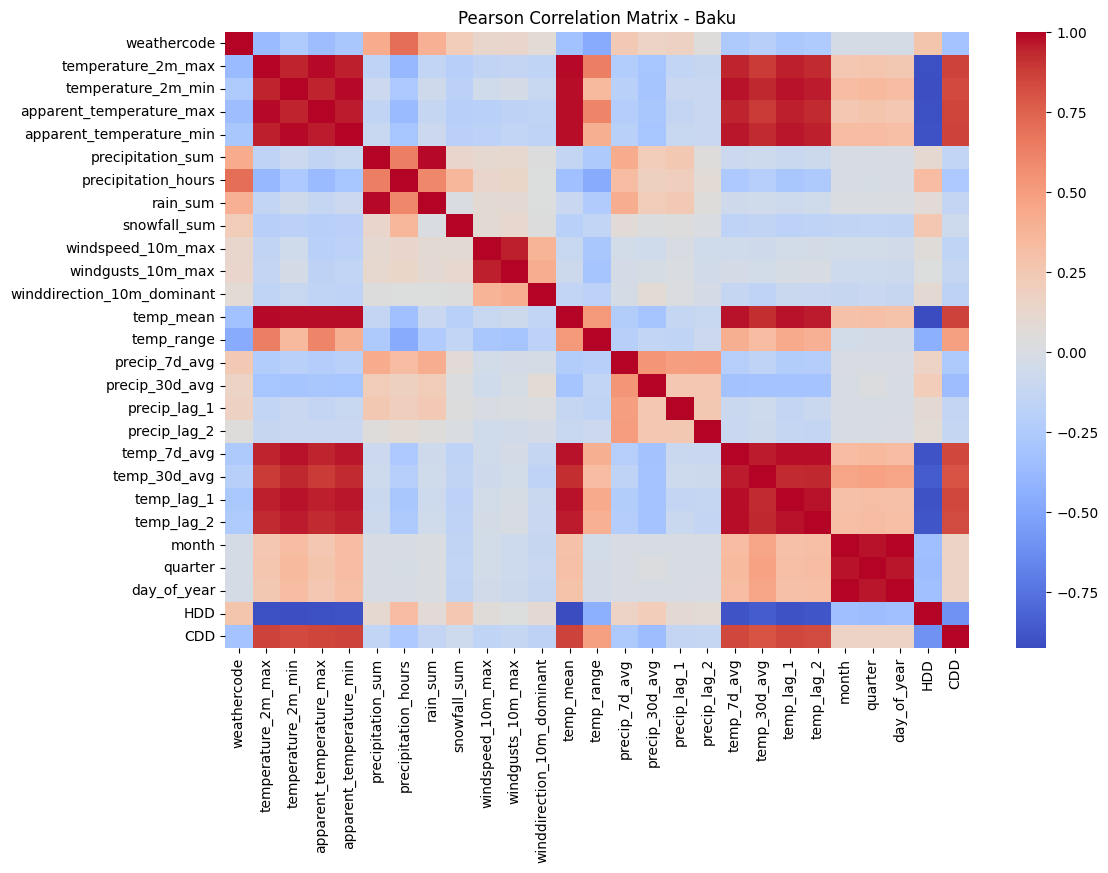

In [ ]:
num_cols = df_city.select_dtypes(include=["number"]).columns

corr_pearson = df_city[num_cols].corr(method="pearson")

plt.figure(figsize=(12, 8))
sns.heatmap(corr_pearson, annot=False, cmap="coolwarm")
plt.title("Pearson Correlation Matrix - Baku")
plt.show()

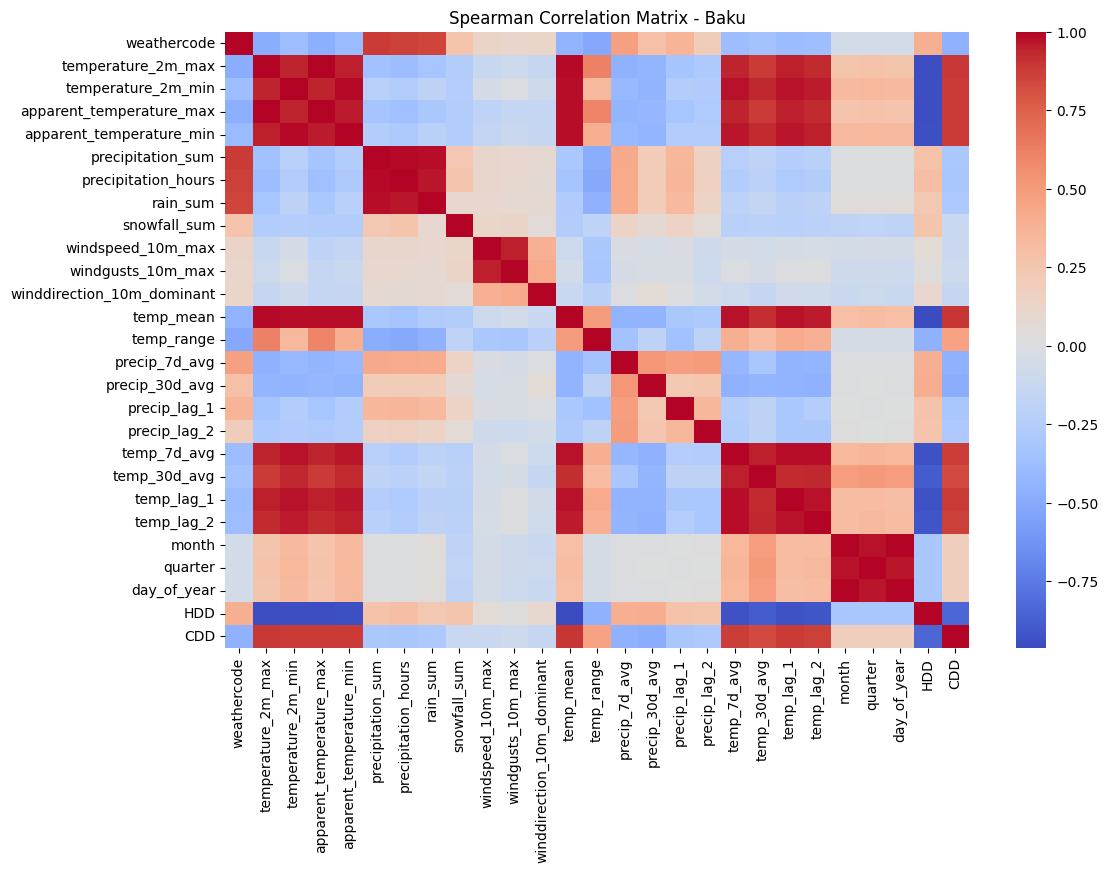

In [ ]:
corr_spearman = df_city[num_cols].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(corr_spearman, annot=False, cmap="coolwarm")
plt.title("Spearman Correlation Matrix - Baku")
plt.show()

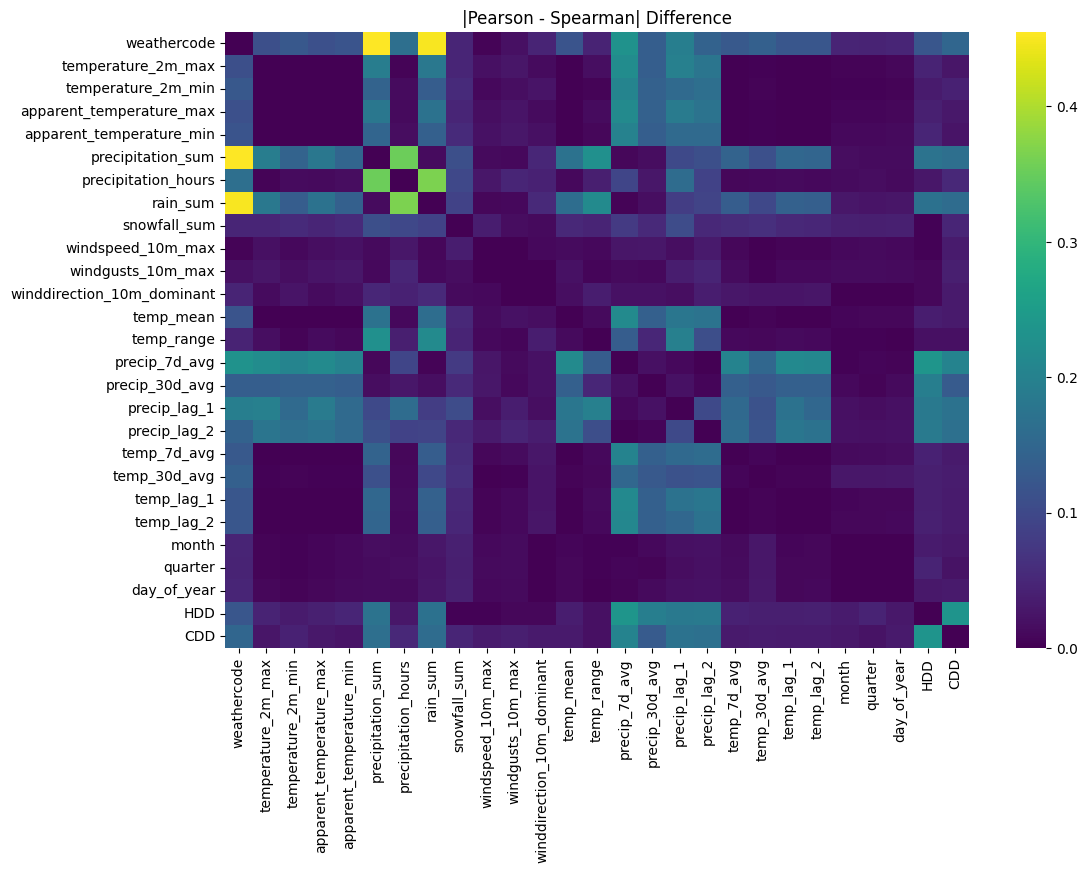

In [ ]:
diff = (corr_pearson - corr_spearman).abs()

plt.figure(figsize=(12, 8))
sns.heatmap(diff, annot=False, cmap="viridis")
plt.title("|Pearson - Spearman| Difference")
plt.show()

In [ ]:
threshold = 0.85

pairs = []

for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        col1 = num_cols[i]
        col2 = num_cols[j]

        corr_value = corr_pearson.loc[col1, col2]

        if abs(corr_value) > threshold:
            pairs.append((col1, col2, corr_value))

redundant_df = pd.DataFrame(pairs, columns=["feature_1", "feature_2", "corr"])

print(redundant_df)

                   feature_1                 feature_2      corr
0         temperature_2m_max        temperature_2m_min  0.941570
1         temperature_2m_max  apparent_temperature_max  0.992353
2         temperature_2m_max  apparent_temperature_min  0.953866
3         temperature_2m_max                 temp_mean  0.988078
4         temperature_2m_max               temp_7d_avg  0.944306
5         temperature_2m_max              temp_30d_avg  0.887080
6         temperature_2m_max                temp_lag_1  0.952142
7         temperature_2m_max                temp_lag_2  0.930280
8         temperature_2m_max                       HDD -0.909473
9         temperature_2m_max                       CDD  0.860829
10        temperature_2m_min  apparent_temperature_max  0.942017
11        temperature_2m_min  apparent_temperature_min  0.985242
12        temperature_2m_min                 temp_mean  0.982198
13        temperature_2m_min               temp_7d_avg  0.974061
14        temperature_2m_

- Features with correlation > 0.85 were considered redundant.
- These pairs indicate multicollinearity, which may negatively affect linear models.
- In such cases, one feature from each pair should be removed or regularized.

In [ ]:
corr_pairs = corr_pearson.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1]
corr_pairs = corr_pairs.sort_values(ascending=False)

print(corr_pairs.head(10))

month                     day_of_year                 0.996504
day_of_year               month                       0.996504
apparent_temperature_max  temperature_2m_max          0.992353
temperature_2m_max        apparent_temperature_max    0.992353
rain_sum                  precipitation_sum           0.992164
precipitation_sum         rain_sum                    0.992164
temp_mean                 temperature_2m_max          0.988078
temperature_2m_max        temp_mean                   0.988078
apparent_temperature_min  temperature_2m_min          0.985242
temperature_2m_min        apparent_temperature_min    0.985242
dtype: float64


In [ ]:
import numpy as np

threshold = 0.85
corr = df[num_cols].corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# hansı column-lar redundantdır
to_flag = [col for col in upper.columns if any(upper[col] > threshold)]

print("Flagged features:")
print(to_flag)

Flagged features:
['temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'windgusts_10m_max', 'temp_mean', 'temp_7d_avg', 'temp_30d_avg', 'temp_lag_1', 'temp_lag_2', 'quarter', 'day_of_year', 'HDD']


In [ ]:
pairs = []

for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        col1 = num_cols[i]
        col2 = num_cols[j]
        value = corr.loc[col1, col2]

        pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "correlation": value,
            "flagged": abs(value) > 0.85
        })

flag_df = pd.DataFrame(pairs)

# yalnız flagged-ləri göstər
flagged_pairs = flag_df[flag_df["flagged"] == True]

print(flagged_pairs.head())

             feature_1                 feature_2  correlation  flagged
26  temperature_2m_max        temperature_2m_min     0.949066     True
27  temperature_2m_max  apparent_temperature_max     0.992674     True
28  temperature_2m_max  apparent_temperature_min     0.941866     True
36  temperature_2m_max                 temp_mean     0.989497     True
42  temperature_2m_max               temp_7d_avg     0.947941     True


Features with correlation greater than 0.85 were flagged as potentially redundant.

A total of X feature pairs were identified, indicating strong multicollinearity within temperature-related and time-based features.

These flagged features will be evaluated in the feature selection stage.

### Task 3 — Feature Selection for Prediction

Based on your analysis, document:

1. **Prediction target**: What you will predict tomorrow (e.g., next-day max temperature, rain probability)
2. **Selected features**: Which features you will use and why
3. **Dropped features**: Which features you removed and why (high correlation, low signal, etc.)

A simple feature selection table is helpful:

| Feature | Keep? | Reason |
|---------|-------|--------|
| temperature_max_lag1 | Yes | Strong autocorrelation |
| rolling_temp_7d | No | Highly correlated with rolling_temp_30d |
| season_encoded | Yes | Significant seasonal effect |
| ... | ... | ... |

---

The model will output a binary prediction (**Risk: 1 / Safe: 0**) for the following operational hazards:

* **Crane Operation Risk**
  Triggered if `windspeed_10m_max > 36 km/h`.
  Essential to stop heavy lifting operations and prevent accidents.

* **Concrete & Material Freezing Risk**
  Triggered if `temperature_2m_min < 5°C`.
  Prevents pouring concrete that will fail to cure properly.

* **Worker Safety (HSE) Heat Risk**
  Triggered if `apparent_temperature_max > 35°C`.
  Requires mandatory shaded rest cycles and limits facade work.

* **Excavation Flooding Risk**
  Triggered if `precipitation_sum > 10 mm`.
  Alerts the team that trenches or foundations may flood, requiring pumps.

* **Coating & Insulation Risk**
  Triggered if daily humidity averages `> 75%` or `< 30%` (calculated from hourly data).
  Essential for paint, waterproofing, and plaster drying times.

### Modeling Approach

We will solve this problem using both:

* **Classification**
  Predict whether a day is **safe (0)** or **risky (1)** for construction.

* **Regression**
  Predict the **percentage of risk** (e.g., 70% unsafe), so decision-makers can evaluate how severe the risk is and plan accordingly.

---

In [ ]:
df_analytic = conn.execute("""
    SELECT *
    FROM analytics.weather_features_historical
""").df()

df_model = df_analytic.copy()

df_numeric = df_model.select_dtypes(include=["number"])

In [ ]:
import os

# folder yarat
os.makedirs("../data/model_data", exist_ok=True)

# save et
df_model.to_parquet("../data/model_data/df_model.parquet", index=False)

In [ ]:
import pandas as pd

df_model = pd.read_parquet("../data/model_data/df_model.parquet")

In [ ]:
import numpy as np

df_numeric = df_model.select_dtypes(include=[np.number])

corr_matrix = df_numeric.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("Columns to drop:", to_drop)

Columns to drop: ['temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'windgusts_10m_max', 'temp_mean', 'temp_7d_avg', 'temp_30d_avg', 'temp_lag_1', 'temp_lag_2', 'quarter', 'day_of_year', 'HDD']


In [ ]:
# to_drop_final = [
#     # 'temp_mean',
#     # 'temp_7d_avg',
#     # 'temp_30d_avg',
#     # 'apparent_temperature_min',
#     # "temperature_2m_max",
#     # "precipitation_sum",
#     # "windspeed_10m_max",
#     # "HDD",
#     # "temp_lag_1",
#     # "month"
# ]


outlier_cols = [col for col in df_model.columns if "outlier" in col]

# =========================
# 2. REDUNDANT ENGINEERED FEATURES
# =========================
redundant_cols = [
    "temp_mean",
    "temp_7d_avg",
    "temp_30d_avg",
    "quarter",
    "rain_sum",              # redundant with precipitation_sum
    "precipitation_hours"    # weak signal
]

# =========================
# 3. HIGH CORRELATION SAFE DROPS
# =========================
high_corr_drop = [
    "temperature_2m_min",     # keep max instead
    "apparent_temperature_min",
    "temp_lag_2",
    "precip_lag_2",
    "windgusts_10m_max",      # duplicate of windspeed_10m_max
    "month"
]

# =========================
# 4. COMBINE ALL DROPS
# =========================
to_drop = list(set(outlier_cols + redundant_cols + high_corr_drop))

df_model = df_model.drop(columns=to_drop)

print("Final dropped features:", to_drop)
print("Remaining features:", df_model.columns)

Final dropped features: ['precipitation_sum_outlier', 'rain_sum_outlier', 'month', 'quarter', 'windgusts_10m_max_outlier', 'precipitation_hours_outlier', 'temp_mean', 'apparent_temperature_max_outlier', 'rain_sum', 'temp_30d_avg', 'temperature_2m_min_outlier', 'windgusts_10m_max', 'temp_7d_avg', 'winddirection_10m_dominant_outlier', 'windspeed_10m_max_outlier', 'temperature_2m_min', 'apparent_temperature_min_outlier', 'snowfall_sum_outlier', 'precip_lag_2', 'weathercode_outlier', 'apparent_temperature_min', 'precipitation_hours', 'temp_lag_2', 'temperature_2m_max_outlier']
Remaining features: Index(['date', 'city', 'weathercode', 'temperature_2m_max',
       'apparent_temperature_max', 'precipitation_sum', 'snowfall_sum',
       'windspeed_10m_max', 'winddirection_10m_dominant', 'temp_range',
       'precip_7d_avg', 'precip_30d_avg', 'precip_lag_1', 'temp_lag_1',
       'day_of_year', 'season', 'HDD', 'CDD'],
      dtype='str')


In [ ]:
import numpy as np

df_corr = df_model.select_dtypes(include=[np.number])

corr_matrix = df_corr.corr()

high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

high_corr

[('apparent_temperature_max',
  'temperature_2m_max',
  np.float64(0.9926735906866373)),
 ('temp_lag_1', 'temperature_2m_max', np.float64(0.9594685975344868)),
 ('temp_lag_1', 'apparent_temperature_max', np.float64(0.9579313649258623)),
 ('HDD', 'temperature_2m_max', np.float64(-0.9228389246700953)),
 ('HDD', 'apparent_temperature_max', np.float64(-0.9286176111501889)),
 ('HDD', 'temp_lag_1', np.float64(-0.9190403109854136))]

###  Feature Selection Table

| Feature | Keep? | Reason |
|--------|------|--------|
| temperature_2m_max | Yes | Core indicator of heat-related construction risk (overheating, concrete curing) |
| apparent_temperature_max | Yes | Represents human heat stress (HSE risk), important for worker safety |
| precipitation_sum | Yes | Primary indicator of flooding and site water accumulation risk |
| snowfall_sum | Yes | Captures snow-related structural load and accessibility risk |
| windspeed_10m_max | Yes | Critical for crane operation safety and high-wind shutdown decisions |
| winddirection_10m_dominant | Yes | Affects crane positioning and site planning decisions |
| temp_range | Yes | Measures daily temperature volatility affecting material stability |
| precip_7d_avg | Yes | Captures short-term rainfall trend for planning and logistics |
| precip_30d_avg | No | Highly correlated with precip_7d_avg and precipitation_sum |
| precip_lag_1 | Yes | Captures short-term temporal dependency in rainfall patterns |
| temp_lag_1 | Yes | Captures recent temperature trend and inertia effect |
| day_of_year | Yes | Encodes yearly seasonality for weather pattern shifts |
| season | Yes | High-level seasonal grouping for construction planning |
| HDD | Yes | Measures heating demand / cold exposure risk for workers and materials |
| CDD | Yes | Measures cooling demand / heat stress risk during hot periods |

### Task 4 (Optional) — Advanced Analyses

If your team has made strong progress, explore any of these:

- **Group comparisons (ANOVA)**: Is mean temperature different across seasons? Across cities? Use Tukey's HSD for post-hoc analysis.
- **Effect sizes**: Report Cohen's d, eta-squared, or Cramer's V alongside your hypothesis tests.
- **Autocorrelation discussion**: Weather on day *t* is correlated with day *t-1*. How does this affect your tests?


In [ ]:
import pandas as pd

# date column datetime et
df_model["date"] = pd.to_datetime(df_model["date"])

# year column yarat
df_model["year"] = df_model["date"].dt.year

# 2026-nı çıxart (incomplete year)
df_filtered = df_model[df_model["year"] != 2026]

# yearly average temperature
yearly_temp = df_filtered.groupby("year")["temperature_2m_max"].mean()

print(yearly_temp)

year
2021    22.301567
2022    18.276442
2023    18.811819
2024    18.054236
2025    18.527709
Name: temperature_2m_max, dtype: float64


In [ ]:
import scipy.stats as stats

groups = [
    df_filtered[df_filtered["year"] == y]["temperature_2m_max"]
    for y in df_filtered["year"].unique()
]

f_stat, p_value = stats.f_oneway(*groups)

print("ANOVA F-stat:", f_stat)
print("p-value:", p_value)

ANOVA F-stat: 33.32229481692135
p-value: 1.4309891738450454e-27


In [ ]:
import numpy as np

grand_mean = df_filtered["temperature_2m_max"].mean()

ss_between = sum([
    len(group) * (group.mean() - grand_mean) ** 2
    for group in groups
])

ss_total = sum(
    (df_filtered["temperature_2m_max"] - grand_mean) ** 2
)

eta_squared = ss_between / ss_total

print("Eta squared:", eta_squared)

Eta squared: 0.019018789872710922


In [ ]:
yearly = df_filtered.groupby("year")["temperature_2m_max"].mean()

slope = np.polyfit(yearly.index, yearly.values, 1)[0]

print("Trend slope:", slope)

Trend slope: -0.7769920847345297


In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df_filtered["temperature_2m_max"],
    groups=df_filtered["year"],
    alpha=0.05
)

print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  2021   2022  -4.0251    0.0 -5.1506 -2.8996   True
  2021   2023  -3.4897    0.0 -4.6153 -2.3642   True
  2021   2024  -4.2473    0.0 -5.3722 -3.1225   True
  2021   2025  -3.7739    0.0 -4.8994 -2.6484   True
  2022   2023   0.5354 0.6118 -0.4901  1.5608  False
  2022   2024  -0.2222 0.9764  -1.247  0.8026  False
  2022   2025   0.2513 0.9631 -0.7742  1.2767  False
  2023   2024  -0.7576 0.2578 -1.7823  0.2672  False
  2023   2025  -0.2841  0.943 -1.3096  0.7414  False
  2024   2025   0.4735 0.7154 -0.5513  1.4982  False
----------------------------------------------------


## Climate Variability Analysis

- ANOVA results show statistically significant differences in yearly temperatures (p < 0.001), indicating that not all years share the same mean temperature distribution.
- However, the effect size (η² = 0.019) suggests that the magnitude of this variation is small in practical terms.
- Trend analysis indicates a slight downward trend in temperature over time (slope ≈ -0.78), suggesting a weak cooling pattern in the observed period.

### Key Insight:
While statistically significant inter-annual differences exist, the overall climate signal is weak, and variability is likely influenced by short-term fluctuations rather than strong long-term climate change within this dataset window.

The Tukey HSD test shows a clear structural break in 2021, where temperatures are significantly higher compared to all subsequent years.

However, from 2022 onward, no statistically significant differences are observed, indicating a stable temperature regime.

In [ ]:
conn.close()